# Meningitis (Kaggle)

## SECCIÓN 0 — DESCRIPCIÓN DEL DATASET

Datos clínicos con **valores faltantes**; foco en imputación.

### Tarea de machine learning
- **Tipo de tarea**: clasificación multiclase
- **Variable objetivo**: `Diagnosis` — tipo (Viral/Bacterial/Unknown).

Las siguientes celdas cargan datos y muestran `head`, `shape`, `dtypes` y `describe`.

In [1]:
import warnings  # Avisos
warnings.filterwarnings("ignore")  # Ocultar
from pathlib import Path  # Rutas
import numpy as np  # Numerico
import pandas as pd  # Tablas
import matplotlib.pyplot as plt  # Graficos
import seaborn as sns  # Stats
from IPython.display import display  # Jupyter
from sklearn.model_selection import train_test_split  # Split
from sklearn.preprocessing import StandardScaler, LabelEncoder  # Escalado
from sklearn.linear_model import LinearRegression, LogisticRegression  # Modelos
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score  # Metricas
ROOT_NB = Path(r"C:/Users/Hp/OneDrive/Escritorio/primerparcial_ia")  # Raiz proyecto

df = pd.read_csv(r"C:/Users/Hp/OneDrive/Escritorio/primerparcial_ia/9. Meningitis Dataset with Missing Values – Kaggle/archive/mening missing 12.csv")  # Cargar
display(df.head(10))  # Muestra
print(df.shape, df.dtypes)  # Info
display(df.describe(include="all").T)  # Stats


,Patient_ID,Age,Gender,WBC_Count,Protein_Level,Glucose_Level,Pathogen_Present,Diagnosis,Outcome,Hemoglobin,WBC_Blood_Count,Platelets,CRP_Level,Risk_Level
0,1,101.0,Female,8624.0,16.0,83.0,No,Viral,Recovered,15.0,7269.0,160949.0,71.0,Moderate Risk
1,2,78.0,Male,22623.0,200.0,41.0,No,Unknown,Recovered,18.0,6532.0,371741.0,41.0,High Risk
2,3,8.0,Female,12908.0,39.0,3.0,No,Unknown,Recovered,16.0,7417.0,180403.0,22.0,Moderate Risk
3,4,104.0,Female,15072.0,58.0,36.0,Yes,Bacterial,Recovered,7.0,13792.0,132254.0,48.0,Moderate Risk
4,5,38.0,Female,18623.0,152.0,34.0,Yes,Bacterial,Recovered,5.0,17054.0,134941.0,28.0,High Risk
5,6,NaN,Female,16688.0,166.0,27.0,Yes,Bacterial,Recovered,5.0,15880.0,116419.0,35.0,High Risk
6,7,NaN,Male,19727.0,171.0,26.0,Yes,Bacterial,Recovered,7.0,14439.0,140626.0,36.0,High Risk
7,8,NaN,Male,16576.0,114.0,1.0,Yes,Bacterial,Recovered,5.0,12982.0,118475.0,25.0,High Risk
8,9,NaN,Male,5848.0,45.0,54.0,No,Viral,Recovered,15.0,7865.0,353841.0,2.0,Low Risk
9,10,NaN,Male,6235.0,45.0,50.0,No,Viral,Recovered,16.0,6739.0,186656.0,0.0,Low Risk


(1200, 14) Patient_ID            int64
Age                 float64
Gender                  str
WBC_Count           float64
Protein_Level       float64
Glucose_Level       float64
Pathogen_Present        str
Diagnosis               str
Outcome                 str
Hemoglobin          float64
WBC_Blood_Count     float64
Platelets           float64
CRP_Level           float64
Risk_Level              str
dtype: object


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Patient_ID,1200.0,NaN,NaN,NaN,600.5,346.554469,1.0,300.75,600.5,900.25,1200.0
Age,1193.0,NaN,NaN,NaN,47.432523,24.571305,0.0,29.0,43.0,61.0,119.0
Gender,1191,2,Male,604,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WBC_Count,1192.0,NaN,NaN,NaN,12130.966443,5670.489634,2017.0,7007.25,12282.0,16895.75,24947.0
Protein_Level,1190.0,NaN,NaN,NaN,109.463866,72.122291,0.0,43.0,108.0,167.0,297.0
Glucose_Level,1192.0,NaN,NaN,NaN,52.633389,34.695494,0.0,26.0,53.0,66.0,149.0
Pathogen_Present,1192,2,No,620,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diagnosis,1188,3,Viral,565,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outcome,1190,2,Recovered,1069,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hemoglobin,1181.0,NaN,NaN,NaN,9.998307,5.577193,1.0,5.0,12.0,15.0,18.0


## SECCIÓN 1

In [2]:
df1 = df.copy()  # Copia para limpiar
print("Nulos ANTES por columna (top):\n", df1.isnull().sum().sort_values(ascending=False).head(15))  # Conteo
df1 = df1.drop_duplicates()  # Eliminar filas duplicadas
nr = df1.isnull().mean()  # Fraccion nulos
drop_null = nr[nr > 0.40].index.tolist()  # Columnas >40% nulos
print("Eliminadas por >40% nulos:", drop_null)  # Motivo: poca informacion
df1 = df1.drop(columns=drop_null, errors="ignore")  # Borrar
num_cols = df1.select_dtypes(include=[np.number]).columns.tolist()  # Numericas
cat_cols = [c for c in df1.columns if c not in num_cols]  # Categoricas
for c in num_cols:
    df1[c] = df1[c].fillna(df1[c].median())  # Mediana (robusta a outliers)
for c in cat_cols:
    if df1[c].isnull().any():
        mod = df1[c].mode()
        df1[c] = df1[c].fillna(mod.iloc[0] if len(mod) else "")  # Moda
print("Nulos DESPUES (total):", int(df1.isnull().sum().sum()))  # Debe ser 0
assert df1.isnull().sum().sum() == 0
df_clean = df1.copy()


Nulos ANTES por columna (top):
 Hemoglobin          19
CRP_Level           13
Diagnosis           12
Platelets           12
Protein_Level       10
WBC_Blood_Count     10
Outcome             10
Gender               9
Glucose_Level        8
WBC_Count            8
Pathogen_Present     8
Age                  7
Patient_ID           0
Risk_Level           0
dtype: int64
Eliminadas por >40% nulos: []
Nulos DESPUES (total): 0


## SECCIÓN 2

X.shape (1200, 12) y.shape (1200,)
Diagnosis
Viral        577
Bacterial    499
Unknown      124
Name: count, dtype: int64


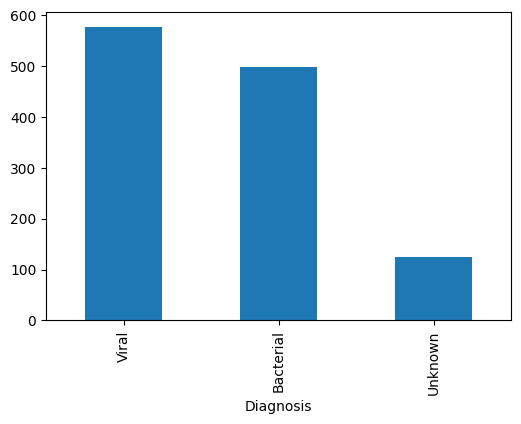

Top 5 correlaciones: Hemoglobin         0.688606
WBC_Blood_Count    0.665048
Platelets          0.587861
WBC_Count          0.579699
Protein_Level      0.553609
dtype: float64


In [3]:
y = df_clean["Diagnosis"]  # Objetivo multiclase
X = df_clean.drop(columns=["Diagnosis"])  # Features
if "Patient_ID" in X.columns:
    X = X.drop(columns=["Patient_ID"])  # Quitar ID
print("X.shape", X.shape, "y.shape", y.shape)  # Shapes
print(y.value_counts())  # Clases
plt.figure(figsize=(6,4))  # Figura
y.astype(str).value_counts().plot(kind="bar")  # Barras
plt.show()  # Grafico
num_x = X.select_dtypes(include=[np.number]).columns  # Numericas
le_y = LabelEncoder().fit_transform(y.astype(str))  # y numerico para corr
corr = X[num_x].corrwith(pd.Series(le_y, index=X.index)).abs().sort_values(ascending=False)  # Corr
print("Top 5 correlaciones:", corr.head(5))  # Top 5


## SECCIÓN 3

In [4]:
X_enc = X.copy()  # Copia
non_num = [c for c in X_enc.columns if not pd.api.types.is_numeric_dtype(X_enc[c])]  # Categoricas
print("Categoricas (antes encoding):", non_num)  # Lista
X_enc = pd.get_dummies(X_enc, columns=non_num, drop_first=False)  # One-hot (nominal)
print("Columnas despues encoding:", X_enc.shape[1])  # Total
display(X_enc.head(5))  # Primeras filas


Categoricas (antes encoding): ['Gender', 'Pathogen_Present', 'Outcome', 'Risk_Level']
Columnas despues encoding: 17


,Age,WBC_Count,Protein_Level,Glucose_Level,Hemoglobin,WBC_Blood_Count,Platelets,CRP_Level,Gender_Female,Gender_Male,Pathogen_Present_No,Pathogen_Present_Yes,Outcome_Deceased,Outcome_Recovered,Risk_Level_High Risk,Risk_Level_Low Risk,Risk_Level_Moderate Risk
0,101.0,8624.0,16.0,83.0,15.0,7269.0,160949.0,71.0,True,False,True,False,False,True,False,False,True
1,78.0,22623.0,200.0,41.0,18.0,6532.0,371741.0,41.0,False,True,True,False,False,True,True,False,False
2,8.0,12908.0,39.0,3.0,16.0,7417.0,180403.0,22.0,True,False,True,False,False,True,False,False,True
3,104.0,15072.0,58.0,36.0,7.0,13792.0,132254.0,48.0,True,False,False,True,False,True,False,False,True
4,38.0,18623.0,152.0,34.0,5.0,17054.0,134941.0,28.0,True,False,False,True,False,True,True,False,False


## SECCIÓN 4

In [5]:
scaler = StandardScaler()  # Escalador
X_scaled = scaler.fit_transform(X_enc)  # Ajuste global
X_scaled_df = pd.DataFrame(X_scaled, columns=X_enc.columns, index=X_enc.index)  # DF
antes = X_enc.iloc[:5, :min(6, X_enc.shape[1])]  # 5 filas antes
despues = X_scaled_df.iloc[:5, :min(6, X_scaled_df.shape[1])]  # 5 filas despues
display(pd.concat([antes, despues], axis=1, keys=["ANTES","DESPUES"]))  # Comparativa


ANTES                                                                   \
     Age WBC_Count Protein_Level Glucose_Level Hemoglobin WBC_Blood_Count   
0  101.0    8624.0          16.0          83.0       15.0          7269.0   
1   78.0   22623.0         200.0          41.0       18.0          6532.0   
2    8.0   12908.0          39.0           3.0       16.0          7417.0   
3  104.0   15072.0          58.0          36.0        7.0         13792.0   
4   38.0   18623.0         152.0          34.0        5.0         17054.0   

    DESPUES                                                                   
        Age WBC_Count Protein_Level Glucose_Level Hemoglobin WBC_Blood_Count  
0  2.188234 -0.620968     -1.301717      0.878462   0.897734       -0.813326  
1  1.249136  1.857082      1.261275     -0.336635   1.439625       -0.962647  
2 -1.608988  0.137369     -0.981343     -1.436008   1.078364       -0.783340  
3  2.310725  0.520433     -0.716686     -0.481289  -0.547310        0.508277  
4 -0.384077  1.149017      0.592669     -0.539151  -0.908572        1.169180

## SECCIÓN 5

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42, stratify=y)  # Estratificado
print("Shapes:", X_train.shape, X_test.shape, y_train.shape, y_test.shape)  # Tamano


Shapes: (960, 17) (240, 17) (960,) (240,)


## SECCIÓN 6

In [7]:
clf = LogisticRegression(max_iter=1000)  # Multiclase
clf.fit(X_train, y_train)  # Entrenar
acc = accuracy_score(y_test, clf.predict(X_test))  # Accuracy
print("Accuracy:", acc)  # Resultado
score_men = acc  # Score


Accuracy: 0.775


## SECCIÓN 7

In [8]:
out = Path(r"C:/Users/Hp/OneDrive/Escritorio/primerparcial_ia/9. Meningitis Dataset with Missing Values – Kaggle")  # Carpeta
pd.concat([X_scaled_df, y.rename("Diagnosis")], axis=1).to_csv(out / "meningitis_clean.csv", index=False)  # Limpio
X_train.to_csv(out / "X_train.csv", index=False)  # Train
X_test.to_csv(out / "X_test.csv", index=False)  # Test
y_train.to_csv(out / "y_train.csv", index=True, header=True)  # y
y_test.to_csv(out / "y_test.csv", index=True, header=True)  # y test
print("Guardado meningitis_clean.csv")  # Ok


Guardado meningitis_clean.csv


## SECCIÓN 8

In [9]:
display(df_clean.head(10))  # Muestra
assert df_clean.isnull().sum().sum() == 0
print("RESUMEN Meningitis | Acc:", round(acc, 4))  # Resumen


,Patient_ID,Age,Gender,WBC_Count,Protein_Level,Glucose_Level,Pathogen_Present,Diagnosis,Outcome,Hemoglobin,WBC_Blood_Count,Platelets,CRP_Level,Risk_Level
0,1,101.0,Female,8624.0,16.0,83.0,No,Viral,Recovered,15.0,7269.0,160949.0,71.0,Moderate Risk
1,2,78.0,Male,22623.0,200.0,41.0,No,Unknown,Recovered,18.0,6532.0,371741.0,41.0,High Risk
2,3,8.0,Female,12908.0,39.0,3.0,No,Unknown,Recovered,16.0,7417.0,180403.0,22.0,Moderate Risk
3,4,104.0,Female,15072.0,58.0,36.0,Yes,Bacterial,Recovered,7.0,13792.0,132254.0,48.0,Moderate Risk
4,5,38.0,Female,18623.0,152.0,34.0,Yes,Bacterial,Recovered,5.0,17054.0,134941.0,28.0,High Risk
5,6,43.0,Female,16688.0,166.0,27.0,Yes,Bacterial,Recovered,5.0,15880.0,116419.0,35.0,High Risk
6,7,43.0,Male,19727.0,171.0,26.0,Yes,Bacterial,Recovered,7.0,14439.0,140626.0,36.0,High Risk
7,8,43.0,Male,16576.0,114.0,1.0,Yes,Bacterial,Recovered,5.0,12982.0,118475.0,25.0,High Risk
8,9,43.0,Male,5848.0,45.0,54.0,No,Viral,Recovered,15.0,7865.0,353841.0,2.0,Low Risk
9,10,43.0,Male,6235.0,45.0,50.0,No,Viral,Recovered,16.0,6739.0,186656.0,0.0,Low Risk


RESUMEN Meningitis | Acc: 0.775
